#LABORATORIO Nº 1  
## Grupo 2
**Alumnos:**


*   Araujo, Facundo
*   Damaria, Leonel
*   Orozco, Lucas
*   Varas, Marí
*   Yohena Tanoni, Brenda


  

# Importación de Librerías

In [26]:
%pip install -q matplotlib seaborn plotly scipy prettytable joypy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import joypy
import seaborn as sns
#
import plotly.express as px
import plotly.graph_objects as go
# Para importación de archivos y acceso a rutas. De apunte de Python
import glob
import os
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px

from itertools import combinations
from collections import Counter

Note: you may need to restart the kernel to use updated packages.


# 1. Carga de datos:


## 1.1 inspeccion de los datasets

In [27]:
# from google.colab import drive
# drive.mount('/content/drive')
# path_dataset = "/content/drive/.shortcut-targets-by-id/1qZi2l_j_yEb9t3Re-7-n3YHA-BJj0DSw/Dataset de ventas/*.csv"

In [28]:
# Creacion de Ruta a la Carpeta del Dataset
path_dataset = "Dataset de ventas/*.csv"


# Listar Archivos
file_list = glob.glob(path_dataset)

# Leer y concatenar los archivos
read_file = [pd.read_csv(f) for f in file_list]



#imprimo la cant de archivos encontrados
print(f"Archivos encontrados: {len(file_list)}")


# Listar los archivos encontrados para control
for archivo in file_list:
    temp = pd.read_csv(archivo)

    print(f"\nArchivo: {os.path.basename(archivo)}")
    print(f"Filas y columnas: {temp.shape}")

    print("\nColumnas:")
    print(temp.columns.tolist())

    print("\nTipos de datos:")
    print(temp.dtypes)

    print("\nPrimeras filas:")
    display(temp.head())



Archivos encontrados: 12

Archivo: Dataset_de_ventas_Abril.csv
Filas y columnas: (18383, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"



Archivo: Dataset_de_ventas_Agosto.csv
Filas y columnas: (12011, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"



Archivo: Dataset_de_ventas_Diciembre.csv
Filas y columnas: (25117, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


...

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,278797,Wired Headphones,1,11.99,11/21/19 09:54,"46 Park St, New York City, NY 10001"
1,278798,USB-C Charging Cable,2,11.95,11/17/19 10:03,"962 Hickory St, Austin, TX 73301"
2,278799,Apple Airpods Headphones,1,150.0,11/19/19 14:56,"464 Cherry St, Los Angeles, CA 90001"
3,278800,27in FHD Monitor,1,149.99,11/25/19 22:24,"649 10th St, Seattle, WA 98101"
4,278801,Bose SoundSport Headphones,1,99.99,11/09/19 13:56,"522 Hill St, Boston, MA 02215"



Archivo: Dataset_de_ventas_Octubre.csv
Filas y columnas: (20379, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,259358,34in Ultrawide Monitor,1,379.99,10/28/19 10:56,"609 Cherry St, Dallas, TX 75001"
1,259359,27in 4K Gaming Monitor,1,389.99,10/28/19 17:26,"225 5th St, Los Angeles, CA 90001"
2,259360,AAA Batteries (4-pack),2,2.99,10/24/19 17:20,"967 12th St, New York City, NY 10001"
3,259361,27in FHD Monitor,1,149.99,10/14/19 22:26,"628 Jefferson St, New York City, NY 10001"
4,259362,Wired Headphones,1,11.99,10/07/19 16:10,"534 14th St, Los Angeles, CA 90001"



Archivo: Dataset_de_ventas_Septiembre.csv
Filas y columnas: (11686, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,248151,AA Batteries (4-pack),4,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"


## 1.2 Creacion e Inspeccion del dataframe

In [29]:
#creo un dataframe con un indice unico e incremental
original_df = pd.concat(read_file, ignore_index=True)

original_df.head()

# a partir de aca se crea una copia del original_df, con la que se va a trabajar para preservar la integridad original de los datos
df = original_df.copy(deep=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID de Pedido        186305 non-null  str  
 1   Producto            186305 non-null  str  
 2   Cantidad Pedida     186305 non-null  str  
 3   Precio Unitario     186305 non-null  str  
 4   Fecha de Pedido     186305 non-null  str  
 5   Dirección de Envio  186305 non-null  str  
dtypes: str(6)
memory usage: 8.6 MB


## 1.3 Dimensiones del dataset

In [30]:
# Cantidad total de registros y variables
filas, columnas = df.shape

print(f"Cantidad de registros: {filas}")
print(f"Cantidad de variables: {columnas}")

Cantidad de registros: 186850
Cantidad de variables: 6


# 2. Limpieza de datos:

## 2.1 Estructura de las columnas

In [31]:
# Columnas presentes en el dataset
print("Columnas presentes:")
for columna in original_df.columns:
    print("-", columna)

Columnas presentes:
- ID de Pedido
- Producto
- Cantidad Pedida
- Precio Unitario
- Fecha de Pedido
- Dirección de Envio


## 2.2 Valores faltantes

In [32]:
# Cantidad de valores faltantes por columna
faltantes = df.isna().sum()

print("filas faltantes")
print(faltantes)

# Porcentaje de valores faltantes por columna
porcentaje_faltantes = df.isna().mean() * 100

print("*********")
print("% de filas faltantes")
print(porcentaje_faltantes)

# filas totalmente vacias
filas_vacias = df.isna().all(axis=1).sum()

print("*********")
print(f"Filas completamente vacías: {filas_vacias}")

# insepecciono las filas vacias
filas_vacias = df[df.isna().all(axis=1)]
print("*********")
print("inspecciono filas vacias")
print(filas_vacias)

filas faltantes
ID de Pedido          545
Producto              545
Cantidad Pedida       545
Precio Unitario       545
Fecha de Pedido       545
Dirección de Envio    545
dtype: int64
*********
% de filas faltantes
ID de Pedido          0.291678
Producto              0.291678
Cantidad Pedida       0.291678
Precio Unitario       0.291678
Fecha de Pedido       0.291678
Dirección de Envio    0.291678
dtype: float64
*********
Filas completamente vacías: 545
*********
inspecciono filas vacias
       ID de Pedido Producto Cantidad Pedida Precio Unitario Fecha de Pedido  \
1               NaN      NaN             NaN             NaN             NaN   
356             NaN      NaN             NaN             NaN             NaN   
735             NaN      NaN             NaN             NaN             NaN   
1433            NaN      NaN             NaN             NaN             NaN   
1553            NaN      NaN             NaN             NaN             NaN   
...             ...      .

## 2.3 Analisis de los valores faltantes
La cantidad de registros con NaN es 545 es igual a la cant de filas con todas sus columnas vacias 545.  Tambien vemos q es un porcentaje bajo de los registros totales del DF por lo cual podemos borrarlas

In [33]:
print("Filas antes de la limpieza:", df.shape[0])
df = df.dropna()
print("Limpiando ...")
print("Filas luego de limpieza:", df.shape[0])

df.head()

Filas antes de la limpieza: 186850
Limpiando ...
Filas luego de limpieza: 186305


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


# 3 Preparacion de los datos

Se realizó una evaluación de la naturaleza de los datos cargados en el dataframe

| Columna              | Tipo actual | Naturaleza    | Tipo esperado    |
| -------------------- | ----------- | ------------- | ---------------- |
| `ID de Pedido`       | `object`    | Identificador | `int64`          |
| `Producto`           | `object`    | Texto         | `string`         |
| `Cantidad Pedida`    | `object`    | Numérico      | `int64`          |
| `Precio Unitario`    | `object`    | Numérico      | `float64`        |
| `Fecha de Pedido`    | `object`    | Fecha/hora    | `datetime64[ns]` |
| `Dirección de Envio` | `object`    | Texto         | `string`         |




In [34]:
# verificamos como esta actualmente
df.info()

<class 'pandas.DataFrame'>
Index: 186305 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID de Pedido        186305 non-null  str  
 1   Producto            186305 non-null  str  
 2   Cantidad Pedida     186305 non-null  str  
 3   Precio Unitario     186305 non-null  str  
 4   Fecha de Pedido     186305 non-null  str  
 5   Dirección de Envio  186305 non-null  str  
dtypes: str(6)
memory usage: 9.9 MB


In [35]:
# Inspeccionamos los valores reales actuales de cada columna del dataframe
for columna in df.columns:
    print(f"\n--- {columna} ---")
    print(df[columna].head(10))



--- ID de Pedido ---
0     176558
2     176559
3     176560
4     176560
5     176561
6     176562
7     176563
8     176564
9     176565
10    176566
Name: ID de Pedido, dtype: str

--- Producto ---
0           USB-C Charging Cable
2     Bose SoundSport Headphones
3                   Google Phone
4               Wired Headphones
5               Wired Headphones
6           USB-C Charging Cable
7     Bose SoundSport Headphones
8           USB-C Charging Cable
9             Macbook Pro Laptop
10              Wired Headphones
Name: Producto, dtype: str

--- Cantidad Pedida ---
0     2
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: Cantidad Pedida, dtype: str

--- Precio Unitario ---
0     11.95
2     99.99
3       600
4     11.99
5     11.99
6     11.95
7     99.99
8     11.95
9      1700
10    11.99
Name: Precio Unitario, dtype: str

--- Fecha de Pedido ---
0     04/19/19 08:46
2     04/07/19 22:30
3     04/12/19 14:38
4     04/12/19 14:38
5     04/30/19 

In [36]:
# traemos los primeros 20 valores disintos de 3 columnas criticas para analizarlas

print(df["Cantidad Pedida"].unique()[:20])
print(df["Precio Unitario"].unique()[:20])
print(df["Fecha de Pedido"].unique()[:20])


<StringArray>
['2', '1', '3', '5', 'Quantity Ordered', '4', '7', '6', '8', '9']
Length: 10, dtype: str
<StringArray>
[     '11.95',      '99.99',        '600',      '11.99',       '1700',
      '14.95',     '389.99',       '3.84',        '150',       '2.99',
        '700',        '300',     '149.99',     '109.99',      '600.0',
     '999.99',        '400',     '379.99', 'Price Each',      '700.0']
Length: 20, dtype: str
<StringArray>
['04/19/19 08:46', '04/07/19 22:30', '04/12/19 14:38', '04/30/19 09:27',
 '04/29/19 13:03', '04/02/19 07:46', '04/12/19 10:58', '04/24/19 10:38',
 '04/08/19 14:05', '04/18/19 17:18', '04/15/19 12:18', '04/16/19 19:23',
 '04/22/19 15:09', '04/19/19 14:29', '04/04/19 20:30', '04/27/19 18:41',
 '04/03/19 19:42', '04/27/19 00:30', '04/28/19 11:42', '04/04/19 19:25']
Length: 20, dtype: str


## 3.1 Deteccion de datos invalidos
Detectamos encabezados incrustados en los datos de las columnas cantidad pedida y precio unitario

In [37]:
# contamos la cantidad de registros con ese error
print("Quantity Ordered:", (df["Cantidad Pedida"] == "Quantity Ordered").sum())
print("Price Each:", (df["Precio Unitario"] == "Price Each").sum())

Quantity Ordered: 355
Price Each: 355


In [38]:
# vemos como estan las otras columnas en esas filas
print(df[df["Cantidad Pedida"] == "Quantity Ordered"])

print(df[df["Precio Unitario"] == "Price Each"])

       ID de Pedido Producto   Cantidad Pedida Precio Unitario  \
519        Order ID  Product  Quantity Ordered      Price Each   
1149       Order ID  Product  Quantity Ordered      Price Each   
1155       Order ID  Product  Quantity Ordered      Price Each   
2878       Order ID  Product  Quantity Ordered      Price Each   
2893       Order ID  Product  Quantity Ordered      Price Each   
...             ...      ...               ...             ...   
185164     Order ID  Product  Quantity Ordered      Price Each   
185551     Order ID  Product  Quantity Ordered      Price Each   
186563     Order ID  Product  Quantity Ordered      Price Each   
186632     Order ID  Product  Quantity Ordered      Price Each   
186738     Order ID  Product  Quantity Ordered      Price Each   

       Fecha de Pedido Dirección de Envio  
519         Order Date   Purchase Address  
1149        Order Date   Purchase Address  
1155        Order Date   Purchase Address  
2878        Order Date   Purcha

## 3.2 Determinacion del tipo de error
que sean 355 los registros con este problema indicaria que no es solamente que cada dataframe tenia su encabezado, ya que serian solo 11 las filas con este inconveniente (la primera es el encabezado real)


In [39]:
# verificamos cuantas filas con ese error hay en los csv originales para descartar
# cualquier error surgido en la concatenacion
import os

print("Cantidad de errores por dataset")
for f, data in zip(file_list, read_file):
    cantidad = (data["Cantidad Pedida"] == "Quantity Ordered").sum()
    print(f"{os.path.basename(f)} → {cantidad}")

Cantidad de errores por dataset
Dataset_de_ventas_Abril.csv → 35
Dataset_de_ventas_Agosto.csv → 26
Dataset_de_ventas_Diciembre.csv → 48
Dataset_de_ventas_Enero.csv → 16
Dataset_de_ventas_Febrero.csv → 18
Dataset_de_ventas_Julio.csv → 35
Dataset_de_ventas_Junio.csv → 23
Dataset_de_ventas_Marzo.csv → 35
Dataset_de_ventas_Mayo.csv → 33
Dataset_de_ventas_Noviembre.csv → 36
Dataset_de_ventas_Octubre.csv → 33
Dataset_de_ventas_Septiembre.csv → 17


## 3.3 Eliminacion de las filas con datos invalidos

In [40]:
# borramos las 545 filas que no tienen datos de nuestro dataframe de trabajo df
df = df[df["Cantidad Pedida"] != "Quantity Ordered"].copy()

#visualizamos como quedo
df.info()
df.shape

<class 'pandas.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID de Pedido        185950 non-null  str  
 1   Producto            185950 non-null  str  
 2   Cantidad Pedida     185950 non-null  str  
 3   Precio Unitario     185950 non-null  str  
 4   Fecha de Pedido     185950 non-null  str  
 5   Dirección de Envio  185950 non-null  str  
dtypes: str(6)
memory usage: 9.9 MB


(185950, 6)

In [41]:
## conversion de datos


## 3.4 Conversion de los tipos de datos

In [42]:
# Conversión de tipos de datos

df["ID de Pedido"] = pd.to_numeric(df["ID de Pedido"]).astype("int64")

df["Producto"] = df["Producto"].astype("string")

df["Cantidad Pedida"] = pd.to_numeric(df["Cantidad Pedida"]).astype("int64")

df["Precio Unitario"] = pd.to_numeric(df["Precio Unitario"]).astype("float64")

df["Fecha de Pedido"] = pd.to_datetime(df["Fecha de Pedido"], format="%m/%d/%y %H:%M")

df["Dirección de Envio"] = df["Dirección de Envio"].astype("string")

# reseteo el indice por las filas que se borraron
df = df.reset_index(drop=True)

df.info()

df.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID de Pedido        185950 non-null  int64         
 1   Producto            185950 non-null  string        
 2   Cantidad Pedida     185950 non-null  int64         
 3   Precio Unitario     185950 non-null  float64       
 4   Fecha de Pedido     185950 non-null  datetime64[us]
 5   Dirección de Envio  185950 non-null  string        
dtypes: datetime64[us](1), float64(1), int64(2), string(2)
memory usage: 8.5 MB


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001"
5,176562,USB-C Charging Cable,1,11.95,2019-04-29 13:03:00,"381 Wilson St, San Francisco, CA 94016"
6,176563,Bose SoundSport Headphones,1,99.99,2019-04-02 07:46:00,"668 Center St, Seattle, WA 98101"
7,176564,USB-C Charging Cable,1,11.95,2019-04-12 10:58:00,"790 Ridge St, Atlanta, GA 30301"
8,176565,Macbook Pro Laptop,1,1700.00,2019-04-24 10:38:00,"915 Willow St, San Francisco, CA 94016"
9,176566,Wired Headphones,1,11.99,2019-04-08 14:05:00,"83 7th St, Boston, MA 02215"


# 4 Analisis de datos

## 4.1 Comportamiento de las ventas en los distintos meses:



### 4.1.1 ¿Cómo variaron las ventas a lo largo de los diferentes meses?

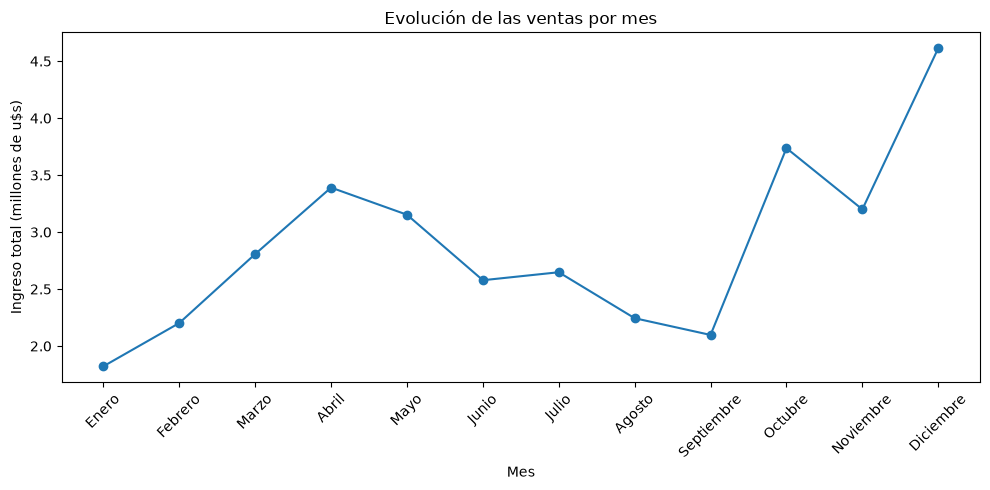

In [43]:
# Calcular el ingreso generado por cada registro
df["Ingreso"] = df["Cantidad Pedida"] * df["Precio Unitario"]

# Extraer el mes de la fecha de pedido
df["Mes"] = df["Fecha de Pedido"].dt.month

# Calcular el ingreso total por mes
ingresos_mensuales = df.groupby("Mes")["Ingreso"].sum().reset_index()

# mostramos el nombre de los meses en lugar del numero
nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

ingresos_mensuales["Nombre Mes"] = ingresos_mensuales["Mes"].map(nombres_meses)

# mostramos la evolucion mensual de las ventas
plt.figure(figsize=(10, 5))

plt.plot(
    ingresos_mensuales["Nombre Mes"],
    ingresos_mensuales["Ingreso"] / 1_000_000,
    marker="o"
)

plt.title("Evolución de las ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ingreso total (millones de u$s)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### 4.1.2 ¿Hubo algún mes que se destacó en términos de ventas?

Mes con mayor ingreso: Diciembre
Ingreso total: 4613443.34


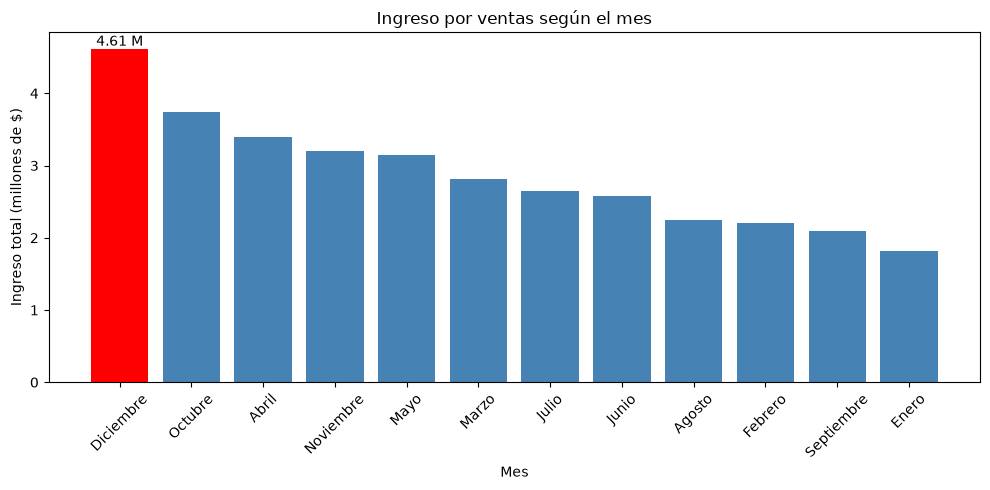

In [44]:
# Buscamos el mes con el mayor ingreso
mes_mayor_venta = ingresos_mensuales.loc[ingresos_mensuales["Ingreso"].idxmax()]

print("Mes con mayor ingreso:", mes_mayor_venta["Nombre Mes"])
print("Ingreso total:", mes_mayor_venta["Ingreso"])

# ordenamos los meses por ingresos de mayor a menor
ingresos_ordenados = ingresos_mensuales.sort_values("Ingreso", ascending=False)

# hacemos el grafico
plt.figure(figsize=(10, 5))

valores = ingresos_ordenados["Ingreso"] / 1_000_000

colores = [
    "red" if mes == mes_mayor_venta["Nombre Mes"] else "steelblue"
    for mes in ingresos_ordenados["Nombre Mes"]
]

plt.bar(
    ingresos_ordenados["Nombre Mes"],
    valores,
    color=colores
)

# Mostrar el valor del mayor ingreso sobre su barra
plt.text(
    0,
    valores.iloc[0],
    f"{valores.iloc[0]:.2f} M",
    ha="center",
    va="bottom"
)

plt.title("Ingreso por ventas según el mes")
plt.xlabel("Mes")
plt.ylabel("Ingreso total (millones de $)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 4.1.3 ¿Cuál es el ingreso total generado por mes?

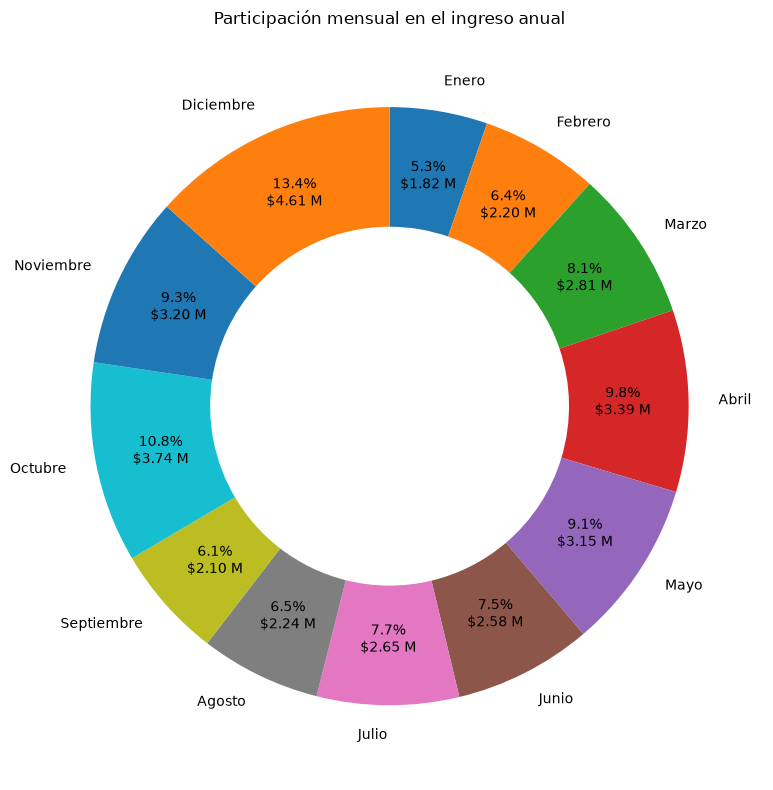

In [45]:
plt.figure(figsize=(8, 8))

def mostrar_porcentaje_y_ventas(porcentaje):
    ingreso = porcentaje / 100 * ingresos_mensuales["Ingreso"].sum()
    ingreso_millones = ingreso / 1_000_000
    return f"{porcentaje:.1f}%\n${ingreso_millones:.2f} M"

plt.pie(
    ingresos_mensuales["Ingreso"],
    labels=ingresos_mensuales["Nombre Mes"],
    autopct=mostrar_porcentaje_y_ventas,
    startangle=90,
    counterclock=False,
    pctdistance=0.78,
    wedgeprops={"width": 0.4}
)

plt.title("Participación mensual en el ingreso anual")

plt.tight_layout()
plt.show()

## 4.2 Optimización de la publicidad y patrón de ventas por hora:


### 4.2.1 ¿Cuál es el momento ideal del día para presentar la publicidad y aumentar la probabilidad de compra?


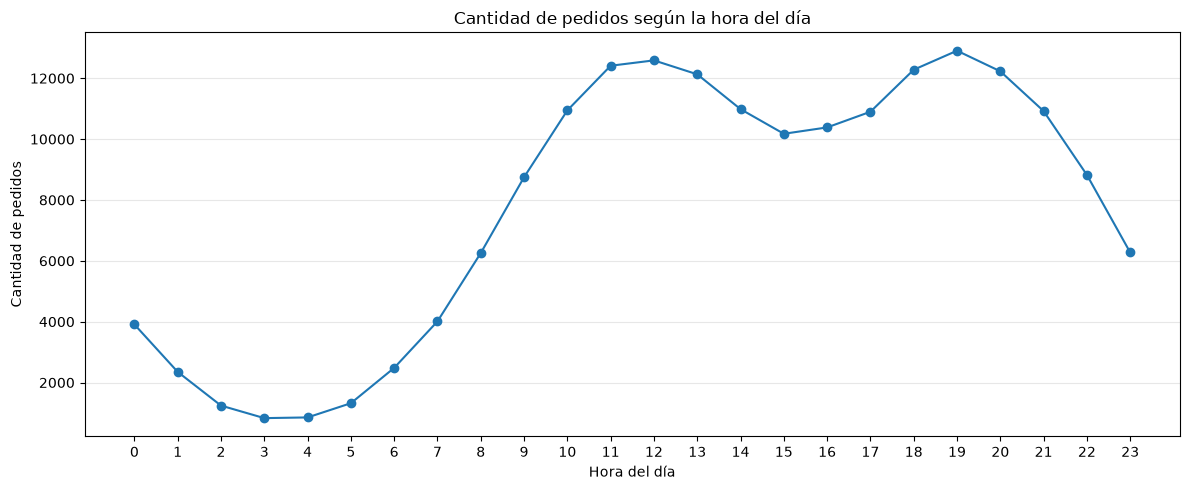

In [46]:
# hacemos el calculo de las ventas por hora
pedidos_por_hora = (
    df["Fecha de Pedido"]
    .dt.hour
    .value_counts()
    .sort_index()
)

# hacemos grafico de puntos del promedio de ventas totales por hora
plt.figure(figsize=(12, 5))

plt.plot(
    pedidos_por_hora.index,
    pedidos_por_hora.values,
    marker="o"
)

plt.title("Cantidad de pedidos según la hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de pedidos")
plt.xticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2.2 ¿Cómo cambian los patrones de ventas por hora a lo largo del año?


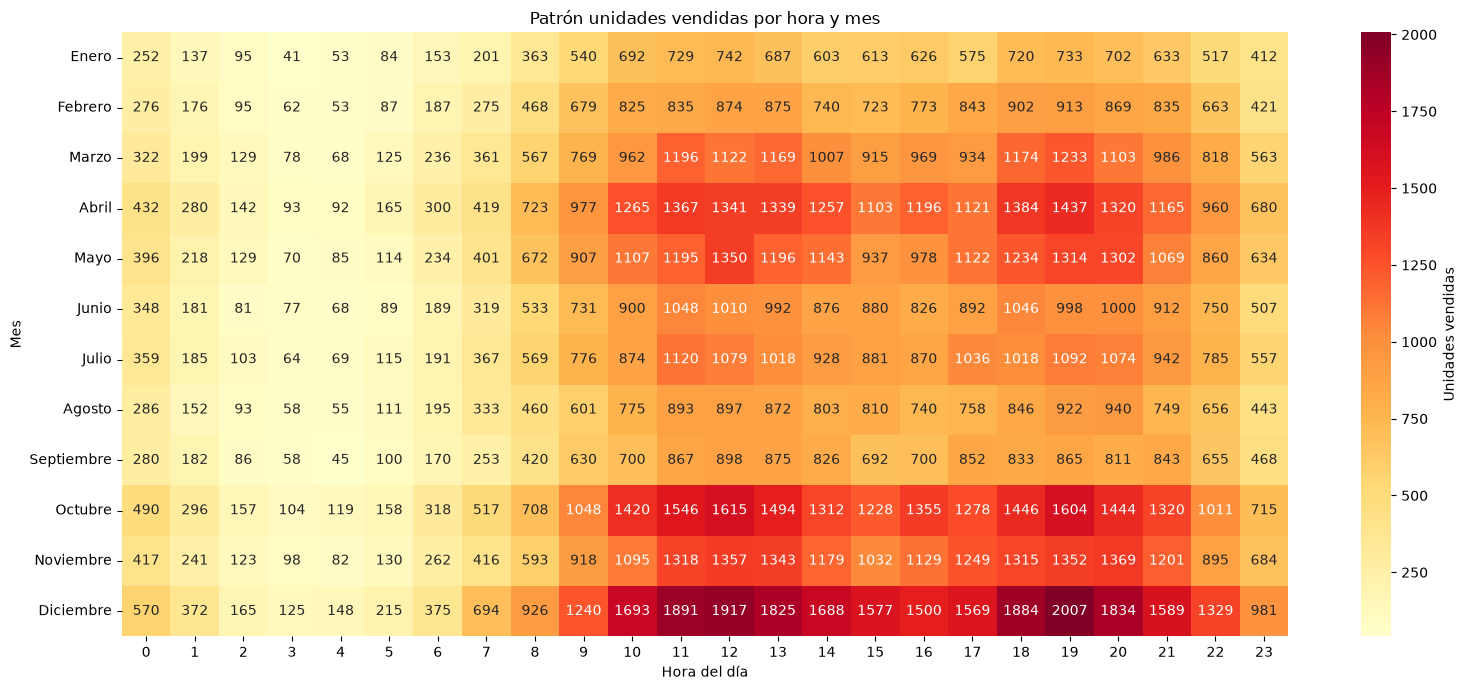

In [47]:
#calculamos las ventas x mes y hora
ventas_mes_hora = (
    df.groupby([
        df["Fecha de Pedido"].dt.month,
        df["Fecha de Pedido"].dt.hour
    ])["Cantidad Pedida"]
    .sum()
    .unstack(fill_value=0)
)

ventas_mes_hora.index = ventas_mes_hora.index.map(nombres_meses)

# realizamos un mapa de calor con el mes, la hora y los pedidos (filas)
plt.figure(figsize=(16, 7))

sns.heatmap(
    ventas_mes_hora,
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Unidades vendidas"}
)

plt.title("Patrón unidades vendidas por hora y mes")
plt.xlabel("Hora del día")
plt.ylabel("Mes")

plt.tight_layout()
plt.show()

### 4.2.3 ¿Hay modificaciones en los patrones de ventas durante las horas de mayor actividad en los distintos meses?

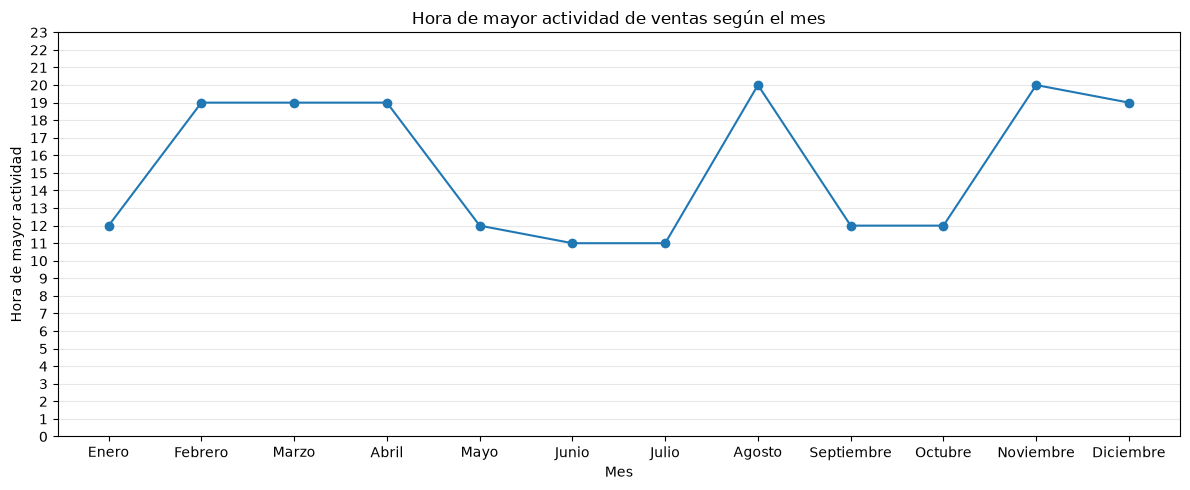

In [48]:
#calculamos como varia la hora de mayor actividad a lo largo de los meses
horas_mayor_actividad = ventas_mes_hora.idxmax(axis=1)


#graficamos la variacion de la hora pico de actividad a lo largo del año
plt.figure(figsize=(12, 5))

plt.plot(
    horas_mayor_actividad.index,
    horas_mayor_actividad.values,
    marker="o"
)

plt.title("Hora de mayor actividad de ventas según el mes")
plt.xlabel("Mes")
plt.ylabel("Hora de mayor actividad")
plt.yticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

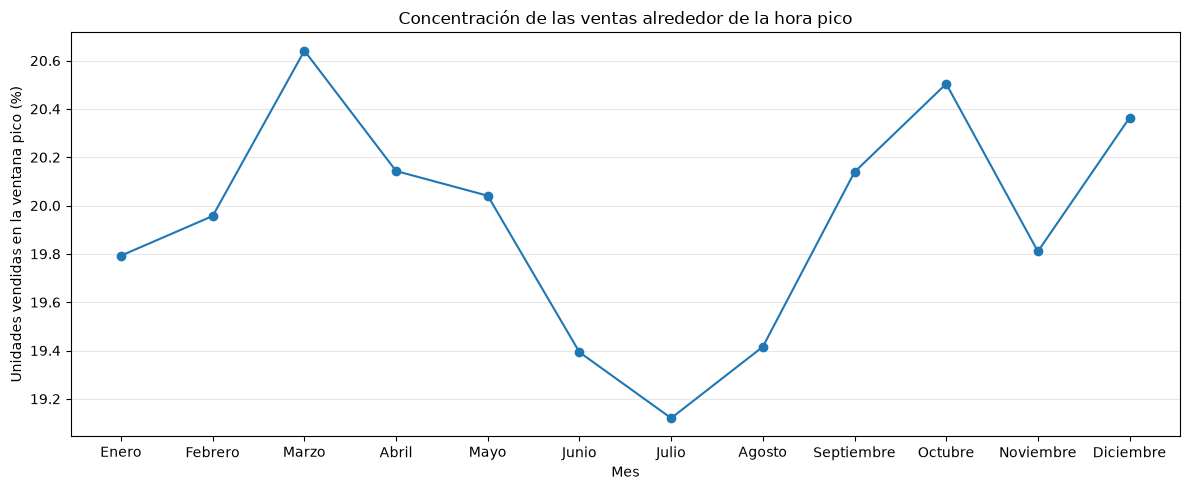

In [49]:
#definimos ahora una franja de 3hs arlededor de la hora pico para ver
#la variacion anual del porcentaje de ventas que ocurre durante esta
#ventana
ventas_franja_pico = {}

for mes in ventas_mes_hora.index:
    hora_pico = horas_mayor_actividad[mes]

    hora_inicio = max(0, hora_pico - 1)
    hora_fin = min(23, hora_pico + 1)

    ventas_franja_pico[mes] = ventas_mes_hora.loc[
        mes,
        hora_inicio:hora_fin
    ].sum()

ventas_franja_pico = pd.Series(ventas_franja_pico)

#calculamos el total de ventas mensuales ocurren en esa ventana
ventas_mensuales = df.groupby(
    df["Fecha de Pedido"].dt.month
)["Cantidad Pedida"].sum()

ventas_mensuales.index = ventas_mensuales.index.map(nombres_meses)

#calculamos ahora el porcentaje que eso representa
porcentaje_franja_pico = (ventas_franja_pico / ventas_mensuales * 100)

#hacemos el grafico
plt.figure(figsize=(12, 5))

plt.plot(
    porcentaje_franja_pico.index,
    porcentaje_franja_pico.values,
    marker="o"
)

plt.title("Concentración de las ventas alrededor de la hora pico")
plt.xlabel("Mes")
plt.ylabel("Unidades vendidas en la ventana pico (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 4.3 Distribución de ventas por ubicación:



### 4.3.1 ¿En qué ciudades se han registrado las mayores ventas? ¿Cómo se comparan las ventas en diferentes estados o regiones?

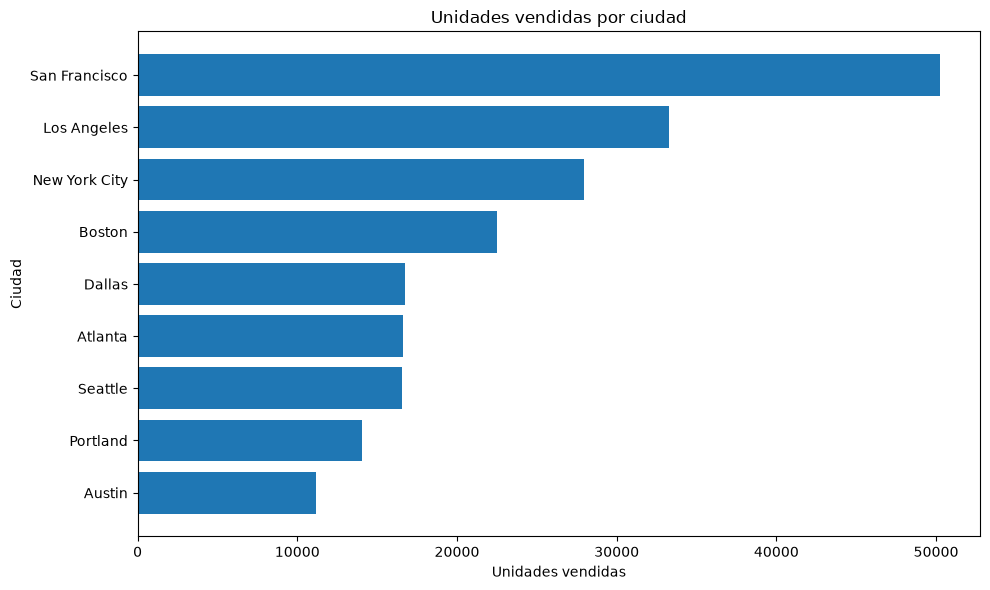

In [50]:
#de la direccion de envio extraemos la ciudad y el estdo
df["Ciudad"] = df["Dirección de Envio"].str.split(", ").str[1]

df["Estado"] = (
    df["Dirección de Envio"]
    .str.split(", ")
    .str[2]
    .str.split(" ")
    .str[0]
)

#si definimos ventas como cantidad de unidades vendidas,
#calculamos ventas x ciudad
ventas_por_ciudad = (
    df.groupby("Ciudad")["Cantidad Pedida"]
    .sum()
    .sort_values(ascending=False)
)

#realizamos el grafico
plt.figure(figsize=(10, 6))

plt.barh(
    ventas_por_ciudad.index[::-1],
    ventas_por_ciudad.values[::-1]
)

plt.title("Unidades vendidas por ciudad")
plt.xlabel("Unidades vendidas")
plt.ylabel("Ciudad")

plt.tight_layout()
plt.show()

